# Telco Customer Churn Prediction

Customer churn occurs when a customer stops using a company's services.
For telecommunication companies, retaining existing customers is often less
expensive than acquiring new ones.

The goal of this project is to identify factors associated with customer churn
and build a model capable of estimating the probability
that a customer will leave the company.

This project focuses on statistical interpretation and model understanding
rather than maximizing predictive performance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Inspection and Quality Assessment

Before performing any analysis, we need to understand the structure and quality
of the dataset.

In particular, we want to identify:

- The number of observations and variables
- Data types of each variable
- Missing values
- Potential formatting issues

Data quality assessment is an important first step because statistical analyses
and predictive models rely on accurate and complete information. Identifying
problems early helps ensure that subsequent conclusions are reliable.

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

df.drop_duplicates(inplace=True)
df.drop(columns=['customerID'], inplace=True)

Duplicate rows: 22


KeyError: "['customerID'] not found in axis"

In [6]:
numeric_charges = pd.to_numeric(df['TotalCharges'], errors='coerce')

non_numeric_rows = df[numeric_charges.isna()]


In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

Overall, the dataset was relatively clean. There were 11 observations where TotalCharges was empty. These observations corresponded to customers with a tenure value of 0, suggesting that they had recently joined the service and had not yet been charged. Therefore, the missing values in TotalCharges were replaced with 0.

# Target Variable Analysis

The target variable in this project is customer churn.

Examining the distribution of the target variable is an important first step
because it reveals how common churn is within the dataset.

The prevalence of churn influences both the business interpretation of the
problem and the evaluation of predictive models.

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


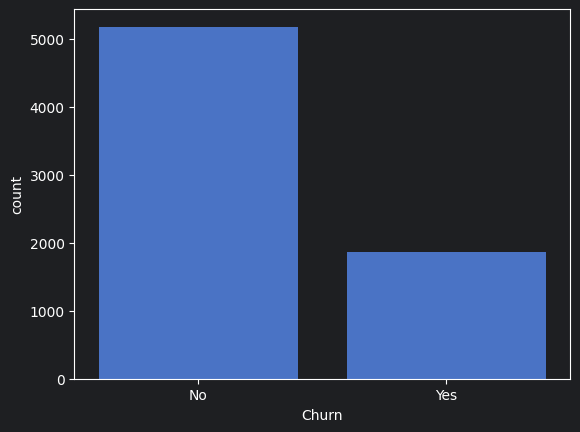

In [10]:
sns.countplot(data=df, x='Churn')

print(df['Churn'].value_counts())

churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_pct.round(2))

Approximately 27% of customers in the dataset churned, while 73% remained with the company.

This indicates that customer churn is a relatively common event in the dataset and represents a meaningful business problem. The target variable is moderately imbalanced, with non-churning customers forming the majority class.

This imbalance should be considered when evaluating model performance, as metrics such as accuracy alone may provide an incomplete assessment.

# Tenure and Customer Churn

Tenure represents the number of months a customer has remained with the company.

Examining the relationship between tenure and churn helps determine whether
customer retention changes over the customer lifecycle.

Comparing the distribution of tenure between churning and non-churning
customers may reveal whether customers are more likely to leave early in
their relationship with the company.

<Axes: xlabel='tenure', ylabel='Count'>

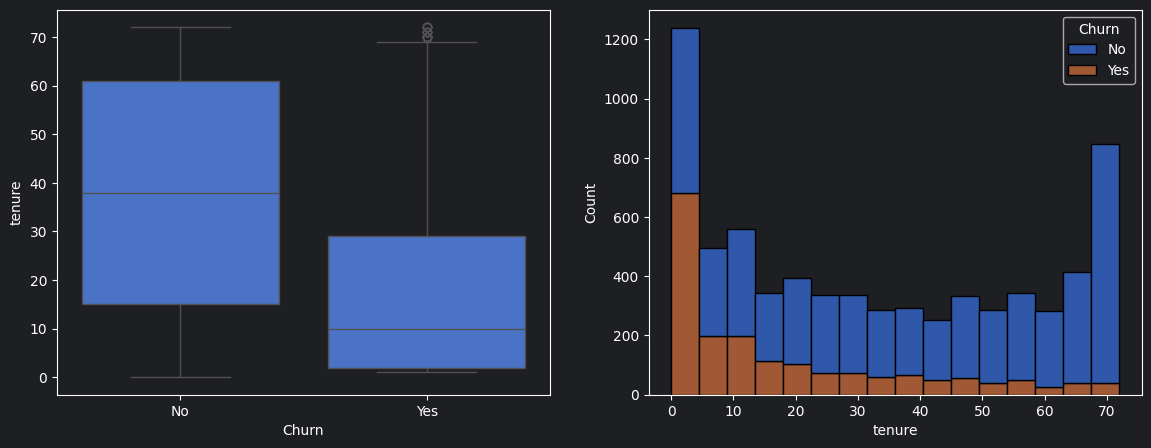

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
axes = ax.flatten()

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
sns.histplot(data=df,x='tenure', hue='Churn', multiple='stack', ax=axes[1])

The exploratory analysis suggests a relationship between tenure and customer churn. Customers who churn generally have shorter tenures, whereas customers with longer tenures are more likely to remain with the company.

### Relationship Between Customer Charges and Churn

Monthly and total charges are continuous variables that may be associated with customer churn. Before fitting a predictive model, it is useful to examine their distributions and compare them between customers who churned and those who remained.

Boxplots provide a summary of the distribution of each variable by churn status, while histograms help visualize whether certain ranges of charges are associated with higher or lower churn rates. These visualizations can reveal patterns that may warrant further investigation in the predictive modeling stage.


<Axes: xlabel='TotalCharges', ylabel='Count'>

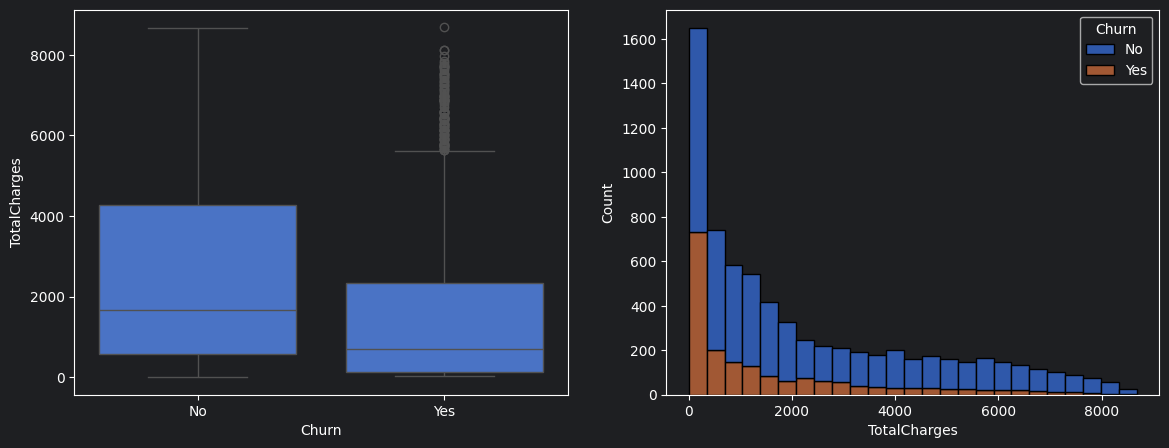

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
axes = ax.flatten()

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[0])
sns.histplot(data=df,x='TotalCharges', hue='Churn', multiple='stack', ax=axes[1])

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

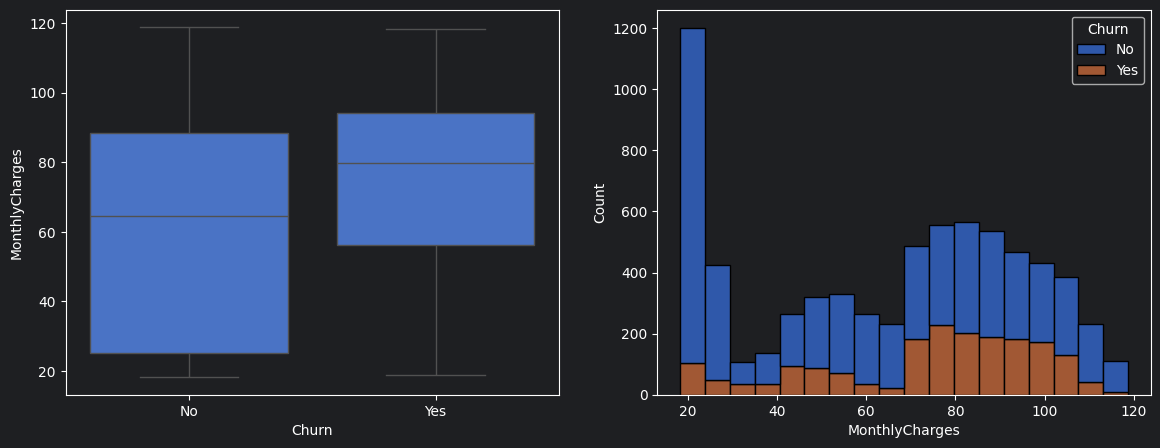

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
axes = ax.flatten()

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0])
sns.histplot(data=df,x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1])

The distribution of Total Charges shows a clear decrease in churn as total charges increase. However, this pattern is likely influenced by customer tenure rather than the amount paid itself. Customers with higher total charges have typically remained with the company for a longer period, making TotalCharges closely related to the tenure variable.

For Monthly Charges, customers with higher monthly bills generally appear more likely to churn than those with lower monthly charges. However, this relationship is not strictly monotonic, as the highest charge ranges exhibit lower churn rates than the preceding bins. Consequently, while there appears to be an association between higher monthly charges and churn, the relationship is not sufficiently consistent to conclude that increasing monthly charges alone leads to higher churn.

# Contract Type and Customer Churn

Contract type may influence customer retention by affecting the level of commitment between the customer and the company.

Examining churn rates across different contract types helps identify whether
certain customer groups are more likely to leave the service.

Understanding these differences may provide valuable insights for customer
retention strategies and will help determine whether contract type is an
important predictor in the logistic regression model.

<Axes: xlabel='Contract', ylabel='Count'>

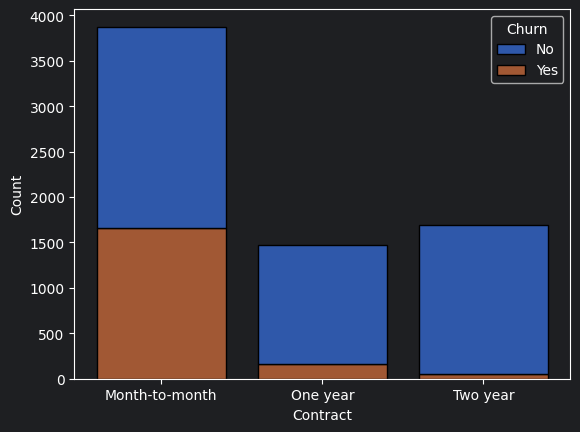

In [14]:
sns.histplot(data=df,x='Contract', hue='Churn', multiple='stack', shrink=0.8)

In [15]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


The exploratory analysis indicates that contract length is associated with customer churn.

Customers with longer-term contracts appear less likely to churn than customers with month-to-month contracts. This pattern suggests that a greater contractual commitment may be associated with higher customer retention.

### Additional Services and Churn

In addition to contract type and pricing, the telecommunications company offers several optional services, such as Online Security, Tech Support, and Streaming. Examining the relationship between these services and customer churn may help identify features associated with customer retention and provide insight into which services appear most valuable to customers.


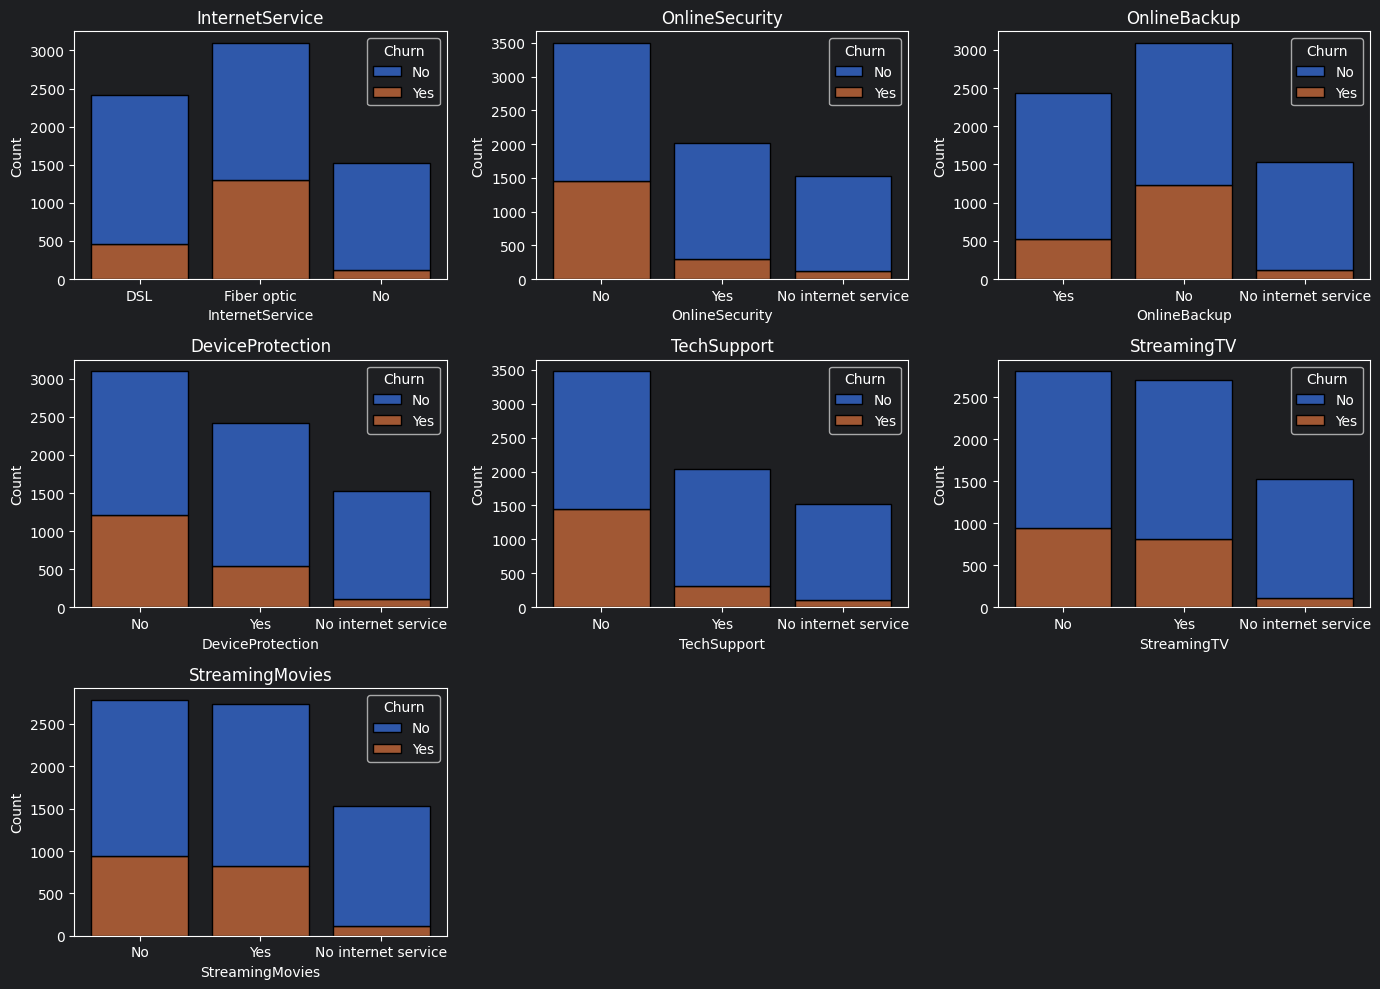

In [16]:
services = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


fig, ax = plt.subplots(3, 3, figsize=(14, 10))
axes = ax.flatten()

for idx, service in enumerate(services):
    sns.histplot(data=df, x=service, hue='Churn', multiple='stack' ,ax=axes[idx], shrink=0.8)
    axes[idx].set_title(service)

for i in range(len(services), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [17]:
for service in services:
    print(pd.crosstab(
        df[service],
        df['Churn'],
        normalize='index'
    ) * 100)
    print("-----------------------------------------")


Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
-----------------------------------------
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194
-----------------------------------------
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494
-----------------------------------------
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064
-----------------------------------------
Churn       

The relationship between service subscriptions and customer churn varies across service categories.

Customers subscribed to Online Security, Online Backup, Device Protection, and Tech Support generally exhibit lower churn rates than those who do not subscribe to these services.

However, Internet Service shows a different pattern, with Fiber Optic customers appearing more likely to churn than DSL customers. In contrast, Streaming TV and Streaming Movies show relatively small differences in churn rates.

Overall, the results suggest that some services are more strongly associated with customer retention than others. As with all exploratory analyses, these findings represent associations rather than causal relationships.


### Exploring the Fiber Optic Relationship

The previous analysis showed that customers with Fiber Optic internet appeared more likely to churn than customers with DSL service. This observation raises an important question: is the higher churn rate associated with the internet service itself, or could it be explained by other customer characteristics?

One possible factor is contract type. Since shorter contracts were previously associated with higher churn, examining the distribution of contract types across internet service categories may provide additional context for the observed relationship.


In [8]:
fiber = df[df['InternetService'] == 'Fiber optic']
dsl = df[df['InternetService'] == 'DSL']

pd.crosstab(
    df['InternetService'],
    df['Contract'],
    normalize='index'
)

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,0.505163,0.235440,0.259397
Fiber optic,0.687339,0.174096,0.138566
No,0.343381,0.238532,0.418087


The distribution of contract types differs substantially between internet service categories. Approximately 69% of Fiber Optic customers are on month-to-month contracts, compared with about 51% of DSL customers. In contrast, DSL customers are more likely to have one-year and two-year contracts.

This suggests that part of the higher churn observed among Fiber Optic customers may be related to their greater prevalence of short-term contracts, which were previously identified as being associated with higher churn. However, contract type alone is unlikely to fully explain the relationship.

### Comparing Fiber Optic and DSL Customers

Contract type explains part of the higher churn observed among Fiber Optic customers, but it is unlikely to provide the full explanation. To better understand this relationship, the following analyses compare additional characteristics of Fiber Optic and DSL customers.

The objective is not to determine the cause of the higher churn rate, but rather to investigate whether Fiber Optic customers differ systematically in other observed variables that are also associated with customer churn.

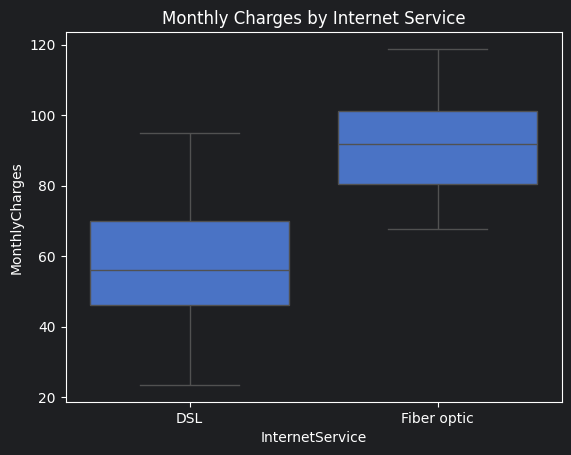

In [31]:
sns.boxplot(
    data=df[df['InternetService'] != 'No'],
    x='InternetService',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Internet Service')
plt.show()

In [33]:
df[df['InternetService'] != 'No'].groupby('InternetService')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
InternetService,,,,,,,,
DSL,2421.0,58.102169,16.259522,23.45,46.20,56.150,69.90,94.80
Fiber optic,3096.0,91.500129,12.663039,67.75,80.55,91.675,101.15,118.75


The comparison shows that Fiber Optic customers pay substantially higher monthly charges than DSL customers, with mean monthly charges of approximately ＄91.5 and ＄58.1, respectively. This difference may partially explain why higher monthly charges appeared to be associated with churn during the exploratory analysis.

This analysis illustrates the importance of investigating relationships between predictors before drawing conclusions from exploratory analyses.

# Preparing the Data for Logistic Regression

The exploratory analysis identified several variables that appear to be associated with customer churn, including tenure, monthly charges, contract type, and service subscriptions.

To quantify these relationships and estimate churn probabilities, a Logistic Regression model will be developed. Before fitting the model, the data must be prepared by converting categorical variables into a numerical format suitable for statistical modeling.

In [9]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

<Axes: >

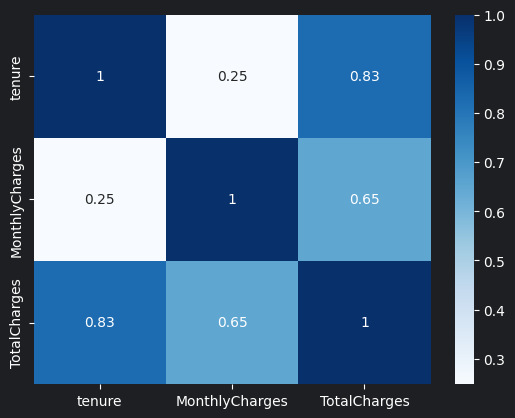

In [14]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

sns.heatmap(
    df[['tenure','MonthlyCharges','TotalCharges']].corr(),
    annot=True,
    cmap='Blues'
)

In [20]:
df.drop(columns=['TotalCharges'], inplace=True)

The Total Charges variable was excluded from the final model because it is highly correlated with both tenure and Monthly Charges, indicating that it largely contains information already represented by these variables. Since the primary objective of this project is to interpret the relationships between customer characteristics and churn rather than maximize predictive accuracy, retaining Total Charges would add redundancy while providing limited additional information. Removing this variable simplifies the interpretation of the model and helps reduce the potential effects of multicollinearity without substantially affecting predictive performance.


In [10]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

# Training and Testing Data

The objective is not only to explain patterns in the current dataset but also to evaluate how well the model performs on unseen observations.

To assess predictive performance, the data is divided into training and testing sets. The model is fitted using the training data and evaluated using the testing data.

In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression

Customer churn is a binary outcome: a customer either churns or remains with the company.

Logistic Regression is a statistical model designed for binary classification problems. Rather than predicting the outcome directly, it estimates the probability that a customer will churn based on their characteristics.

An additional advantage of Logistic Regression is that the estimated coefficients can be interpreted, providing insight into which factors are most strongly associated with customer churn.

## Logistic Regression Assumptions

Like all statistical models, Logistic Regression relies on several assumptions.

* Independent observations
* Limited multicollinearity
* Linear relationship between continuous predictors and the log-odds
* Absence of influential outliers

These assumptions should be considered when interpreting the model.

In [23]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

The default optimization settings produced a convergence warning, indicating that the solver had not fully converged. The maximum number of iterations was increased to allow the optimization procedure to reach a stable solution.

In [24]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df

,Feature,Coefficient
9,InternetService_Fiber optic,1.330755
22,StreamingMovies_Yes,0.449944
20,StreamingTV_Yes,0.448992
8,MultipleLines_Yes,0.410496
27,PaymentMethod_Electronic check,0.382867
25,PaperlessBilling_Yes,0.368485
7,MultipleLines_No phone service,0.186142
0,SeniorCitizen,0.146055
28,PaymentMethod_Mailed check,0.103603
16,DeviceProtection_Yes,0.083785


# Odds Ratios

The coefficients produced by Logistic Regression are expressed in terms of log-odds, which can be difficult to interpret directly.

Exponentiating the coefficients converts them into odds ratios. An odds ratio greater than 1 indicates higher odds of churn, while an odds ratio less than 1 indicates lower odds of churn.

Odds ratios provide a more intuitive way to quantify the relationship between customer characteristics and churn.

In [25]:
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

coef_df.sort_values(
    by='Odds_Ratio',
    ascending=False
)

,Feature,Coefficient,Odds_Ratio
9,InternetService_Fiber optic,1.330755,3.783900
22,StreamingMovies_Yes,0.449944,1.568225
20,StreamingTV_Yes,0.448992,1.566732
8,MultipleLines_Yes,0.410496,1.507565
27,PaymentMethod_Electronic check,0.382867,1.466483
25,PaperlessBilling_Yes,0.368485,1.445542
7,MultipleLines_No phone service,0.186142,1.204593
0,SeniorCitizen,0.146055,1.157260
28,PaymentMethod_Mailed check,0.103603,1.109160
16,DeviceProtection_Yes,0.083785,1.087395


The Logistic Regression model confirmed several of the relationships identified during the exploratory analysis while simultaneously accounting for the influence of the remaining predictors.

The strongest positive association with churn was observed for Fiber Optic internet service (OR = 3.57). Earlier exploratory analysis suggested that Fiber Optic customers were more likely to have month-to-month contracts, partially explaining their higher churn rates. However, the logistic regression model identified Fiber Optic service as a strong predictor even after controlling for contract type and the other variables, indicating that its association with churn is not fully explained by contract type alone.

Contract type exhibited the strongest negative association with churn. Customers on one-year contracts had approximately 49% lower odds of churn than customers on month-to-month contracts (OR = 0.50), while customers on two-year contracts had approximately 73% lower odds of churn (OR = 0.27).

Online Security and Tech Support were also associated with lower odds of churn, suggesting that customers subscribed to these services tend to have lower odds of churning.

Tenure was negatively associated with churn (OR = 0.95). Because tenure is a continuous variable, this odds ratio represents the effect of a one-month increase in tenure. Holding all other variables constant, each additional month of tenure was associated with approximately 5% lower odds of churn.

Interestingly, Monthly Charges appeared positively associated with churn during the exploratory analysis but exhibited only a small negative association in the logistic regression model. This suggests that the apparent relationship observed during the exploratory analysis was influenced by other customer characteristics. This difference highlights one of the main advantages of Logistic Regression: it estimates the association between each predictor and churn while controlling for the effects of the remaining variables.


# Model Evaluation

Interpreting the model coefficients helps identify which customer characteristics are associated with churn. However, understanding these relationships is only one objective of the analysis.

It is also important to evaluate how well the model predicts churn for unseen customers. Several classification metrics will be used to assess predictive performance, including accuracy, precision, recall, F1-score, and ROC-AUC.

Together, these metrics provide a more complete assessment of model performance than any single metric alone.

In [26]:
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

## Classification Metrics

Different metrics evaluate different aspects of classification performance.

- Accuracy measures the proportion of correct predictions.
- Precision measures how often customers predicted to churn actually churn.
- Recall measures how many churning customers are correctly identified.
- F1-score balances precision and recall.
- ROC-AUC measures the model's ability to distinguish between churning and non-churning customers across different classification thresholds.

Because customer churn is less common than customer retention, relying solely on accuracy may provide a misleading assessment of model performance.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score, confusion_matrix
)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.3f}")

Accuracy: 0.798
Precision: 0.639
Recall: 0.545
F1 Score: 0.589
ROC-AUC: 0.839


The Logistic Regression model achieved an accuracy of 79.8%, correctly classifying approximately four out of five customers in the test set. However, because the dataset contains substantially more non-churning than churning customers, accuracy alone does not provide a complete assessment of model performance.

The model achieved a precision of 63.9%, indicating that nearly two-thirds of customers predicted to churn actually did so. The recall of 54.5% shows that the model correctly identified just over half of the customers who ultimately churned. Consequently, while the model is reasonably reliable when predicting churn, a substantial proportion of customers who churn are not identified.

The F1-score of 0.589 reflects a moderate balance between precision and recall. The strongest overall performance measure was the ROC-AUC of 0.839, indicating that the model has good ability to distinguish between customers who churn and those who remain across different classification thresholds.


## Confusion Matrix

The confusion matrix provides a detailed breakdown of the model's predictions.

- True Positives: customers who churned and were correctly identified.
- True Negatives: customers who remained and were correctly identified.
- False Positives: customers predicted to churn who did not churn.
- False Negatives: customers who churned but were not identified by the model.

Examining these outcomes helps evaluate the practical consequences of prediction errors.

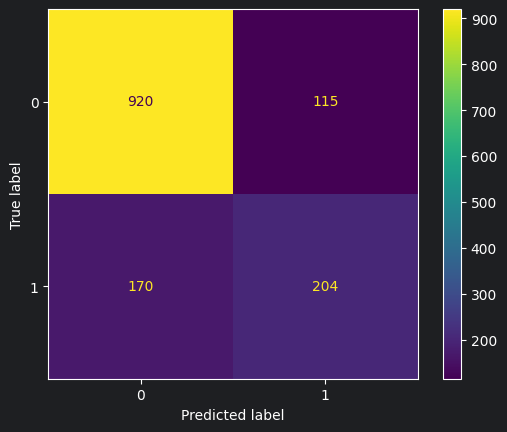

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

The confusion matrix provides additional insight into the model's predictions. The model correctly classified 920 customers who remained (true negatives) and 240 customers who churned (true positives). It incorrectly identified 115 customers as likely to churn when they did not (false positives) and failed to identify 170 customers who ultimately churned (false negatives).

From a business perspective, false negatives are typically the more costly error because these customers leave without receiving any retention effort. In contrast, false positives result in retention resources being directed toward customers who would have remained with the company. The presence of more false negatives than false positives suggests that lowering the classification threshold may improve the model's ability to identify customers at risk of churn, although this would come at the expense of reduced precision.


## ROC Curve

The ROC curve illustrates the trade-off between the true positive rate (recall) and the false positive rate across different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the model's ability to distinguish between churning and non-churning customers. A value of 0.5 indicates no discriminatory power, while a value of 1.0 indicates perfect classification.

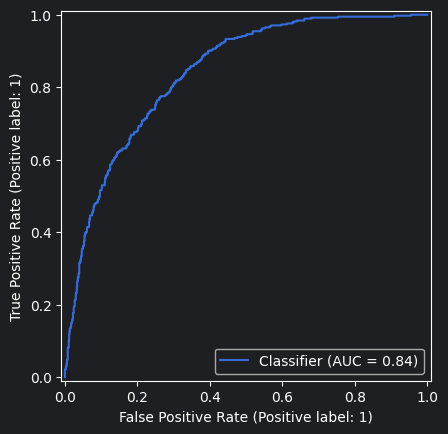

In [29]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_prob
)

For customer churn prediction, correctly identifying customers who are likely to churn is typically more important than minimizing false positives. In other words, maximizing recall may be prioritized depending on business objectives, even if it results in a larger number of customers being incorrectly classified as potential churners.

The cost of a false positive is that a customer who would have remained with the company may receive unnecessary retention efforts, such as discounts or promotional offers. However, the cost of a false negative is often higher, as a customer who is likely to churn receives no intervention and may be permanently lost. If the retention strategy is effective and cost-efficient, correctly identifying customers at risk of churn can outweigh the additional cost associated with false positives.


# Improving Recall Through Threshold Selection

The previous evaluation showed that the model correctly identified approximately 55% of customers who churned. In customer churn prediction, however, failing to identify a customer who is likely to leave is often more costly than incorrectly classifying a customer as being at risk.

Consequently, maximizing recall is frequently prioritized, even if it results in a larger number of false positives. While false positives may lead to unnecessary retention efforts, false negatives represent customers who receive no intervention and may be permanently lost.

Rather than retraining the model, one way to increase recall is to adjust the classification threshold. By lowering the threshold below the default value of 0.5, more customers are classified as potential churners, increasing recall while typically reducing precision and overall accuracy.

The following analysis explores this trade-off across several classification thresholds.


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

results = pd.DataFrame(results)
results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.50,0.797729,0.639498,0.545455,0.588745
1,0.45,0.792051,0.608579,0.606952,0.607764
2,0.40,0.777857,0.569794,0.665775,0.614057
3,0.35,0.765791,0.545455,0.705882,0.615385
4,0.30,0.750887,0.521739,0.737968,0.611296


## Effect of the Classification Threshold

Lowering the classification threshold increases the model's ability to identify customers who are likely to churn, resulting in higher recall. However, this improvement comes at the expense of lower precision and overall accuracy, as more non-churning customers are incorrectly classified as potential churners.

The results illustrate the trade-off between precision and recall in binary classification. Rather than selecting a single "optimal" threshold, the appropriate choice depends on the business objective and the relative cost of false positives and false negatives.

For customer churn prediction, where failing to identify a customer at risk of leaving may be more costly than contacting a customer who would have remained, a lower classification threshold may be preferable. Nevertheless, the final threshold should be determined based on business requirements rather than statistical performance alone.

# Limitations and Future Work

Although the Logistic Regression model achieved good predictive performance, several limitations should be considered when interpreting the results.

First, the model identifies associations rather than causal relationships. For example, longer contract durations are associated with lower observed churn rates, but this does not imply that simply changing a customer's contract will necessarily reduce churn.

Second, the analysis is based on historical data from a single telecommunications company. Consequently, the findings may not generalize to other companies or markets. Furthermore, customer churn is influenced by factors that are not included in the dataset, such as customer satisfaction, service quality, competitor pricing, and previous interactions with customer support.

Future work could explore additional customer features, apply feature engineering techniques, and evaluate alternative classification models such as decision trees or ensemble methods. Cross-validation and more extensive model comparison could also be performed to assess the robustness of the results and determine whether predictive performance can be further improved.


# Conclusion

The objective of this project was to identify customer characteristics associated with churn and evaluate the effectiveness of Logistic Regression for predicting customer churn.

The exploratory analysis identified several variables associated with churn, including tenure, contract type, internet service, monthly charges, and additional service subscriptions. Further investigation showed that some of these variables were also related to one another, illustrating the importance of considering multiple predictors simultaneously.

The Logistic Regression model confirmed many of the patterns observed during the exploratory analysis while demonstrating that some apparent relationships changed after controlling for the remaining variables. In particular, contract type, Fiber Optic internet service, tenure, Online Security, and Tech Support emerged as some of the strongest predictors of customer churn. The analysis also illustrated that relationships observed during exploratory analysis, such as the association between monthly charges and churn, may be influenced by other customer characteristics.

The final model achieved good predictive performance, with an ROC-AUC of **0.839**, indicating a strong ability to distinguish between customers who churn and those who remain. Adjusting the classification threshold further demonstrated the trade-off between precision and recall, highlighting how model performance can be tailored to different business objectives.

Overall, this project demonstrates how exploratory data analysis and Logistic Regression can be combined to understand customer behavior, quantify the relationship between multiple predictors and churn, and support data-driven decision making. It also highlights the importance of interpreting statistical models alongside exploratory analyses to obtain a more complete understanding of the underlying data.
